# M18 · RAG (Retrieval-Augmented Generation) — ✍️ Toy Examples, Step by Tiny Step

**Companion to lesson M18. Written for someone new to ML.**

RAG means **Retrieval-Augmented Generation**: first **retrieve** relevant text from a small knowledge
base, then **generate** an answer that is grounded in that text. In this notebook, "generate" is
simulated with a simple offline function — no real LLM, no HuggingFace, no network, and no downloads.

**What you'll build (every topic has a marked Toy example, printed numbers, and a picture):**
- A mini company FAQ **corpus** (a corpus is a collection of documents).
- **Chunks** (small pieces of text) and a TF-IDF **embedding index** (vectors we can search).
- **Cosine similarity** retrieval for top-k chunks.
- An **augmented prompt** that shows exactly what a generator would receive.
- A simulated grounded answer with **citations** and a safe **I don't know** fallback.
- Simple evaluation ideas: **recall@k**, stale indexes, and chunking/embedding gotchas.

## Step 0 · Setup

Import NumPy (arrays), Pandas (tables), scikit-learn (TF-IDF text vectors), and Matplotlib
(pictures). Fix the **seed** so the notebook is reproducible, set a default figure size, and define
a tiny `log()` helper for readable printouts.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4)

def log(label, value):
    print(f"[{label}] {value}")

log("setup", "ready — NumPy + Pandas + scikit-learn + Matplotlib imported, seed fixed to 0")

[setup] ready — NumPy + Pandas + scikit-learn + Matplotlib imported, seed fixed to 0


---
# Part A · Build the RAG search engine

## Step 1 · Toy example — the problem RAG solves

A plain language model may not know **fresh** facts, **private** facts, or tiny facts from your own
company docs. If it answers anyway, it can **hallucinate** (make something up that sounds confident).

RAG changes the job:
1. **Retrieve** the most relevant text from a trusted corpus.
2. **Generate** using that retrieved text as evidence.

Plain-English pipeline:

`corpus → chunk → embed → index → query → embed query → retrieve top-k → augment prompt → generate`

RAG pipeline, in order:
  1. corpus
  2. chunk
  3. embed
  4. index
  5. query
  6. embed query
  7. retrieve top-k
  8. augment prompt
  9. generate
Key idea: the answerer only sees the retrieved context, not the whole world.


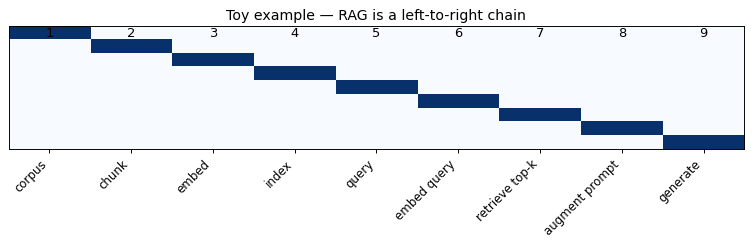

In [5]:
pipeline = [
    "corpus", "chunk", "embed", "index",
    "query", "embed query", "retrieve top-k", "augment prompt", "generate"
]
print("RAG pipeline, in order:")
for i, step in enumerate(pipeline, 1):
    print(f"  {i}. {step}")
print("Key idea: the answerer only sees the retrieved context, not the whole world.")

diagram = np.eye(len(pipeline))
plt.figure(figsize=(9, 3))
plt.imshow(diagram, cmap="Blues", aspect="auto")
plt.xticks(range(len(pipeline)), pipeline, rotation=45, ha="right")
plt.yticks([])
for i, step in enumerate(pipeline):
    plt.text(i, 0, str(i + 1), ha="center", va="center", color="black", fontsize=11)
plt.title("Toy example — RAG is a left-to-right chain")
plt.tight_layout()
plt.show()

**Good for:** answering from a known knowledge base, private docs, or facts that change often.

**Watch out for:** RAG does not magically make bad context true. If retrieval misses the right chunk,
generation can still be wrong.

## Step 2 · Toy example — corpus → chunks

A **corpus** is the full collection of text. A **chunk** is a smaller piece we search over. We use a
tiny fake company FAQ so every fact is visible.

Documents: 7
Chunks: 9
chunk_id doc_id           title                                                                             text
     C00     D1 Vacation policy                          Full-time employees receive 15 vacation days each year.
     C01     D1 Vacation policy                                   Interns receive 5 vacation days during summer.
     C02     D2  Password reset                                    Reset your password from the security portal.
     C03     D2  Password reset                                           A reset link expires after 20 minutes.
     C04     D3   Lunch benefit      The company cafe gives every employee a 12 dollar lunch credit on weekdays.
     C05     D4     Remote work       Team members may work remotely on Monday and Friday with manager approval.
     C06     D5     Office pets Dogs are allowed in the office on Friday if they are registered with facilities.
     C07     D6  Data retention                    Customer analytics log

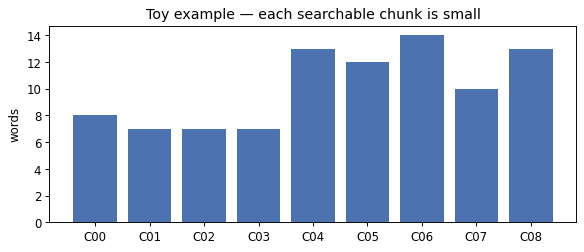

In [8]:
docs = [
    {"doc_id": "D1", "title": "Vacation policy",
     "text": "Full-time employees receive 15 vacation days each year. Interns receive 5 vacation days during summer."},
    {"doc_id": "D2", "title": "Password reset",
     "text": "Reset your password from the security portal. A reset link expires after 20 minutes."},
    {"doc_id": "D3", "title": "Lunch benefit",
     "text": "The company cafe gives every employee a 12 dollar lunch credit on weekdays."},
    {"doc_id": "D4", "title": "Remote work",
     "text": "Team members may work remotely on Monday and Friday with manager approval."},
    {"doc_id": "D5", "title": "Office pets",
     "text": "Dogs are allowed in the office on Friday if they are registered with facilities."},
    {"doc_id": "D6", "title": "Data retention",
     "text": "Customer analytics logs are kept for 30 days before deletion."},
    {"doc_id": "D7", "title": "Support hours",
     "text": "IT support answers urgent tickets from 8 AM to 6 PM Eastern time."},
]

def sentence_chunks(text):
    pieces = [s.strip() for s in text.split(".") if s.strip()]
    return [p + "." for p in pieces]

chunks = []
for doc in docs:
    for sent_no, sent in enumerate(sentence_chunks(doc["text"])):
        chunks.append({
            "chunk_id": f"C{len(chunks):02d}",
            "doc_id": doc["doc_id"],
            "title": doc["title"],
            "sentence": sent_no,
            "text": sent,
        })

chunk_df = pd.DataFrame(chunks)
print("Documents:", len(docs))
print("Chunks:", len(chunks))
print(chunk_df[["chunk_id", "doc_id", "title", "text"]].to_string(index=False))

lengths = [len(c["text"].split()) for c in chunks]
print("Chunk lengths in words:", lengths)
assert len(chunks) == 9
assert chunks[1]["text"] == "Interns receive 5 vacation days during summer."

plt.figure(figsize=(8, 3))
plt.bar([c["chunk_id"] for c in chunks], lengths, color="#4C72B0")
plt.ylabel("words")
plt.title("Toy example — each searchable chunk is small")
plt.show()

**Good for:** small chunks make retrieval focused: the answerer sees the fact it needs.

**Watch out for:** too big = noisy context; too small = lost meaning. Chunk size is a design choice,
not a law.

## Step 3 · Toy example — chunking tradeoff

Here is the same sentence chopped three ways. We print the exact pieces so you can see why chunking is
a balance.

Original text: Interns receive 5 vacation days during summer and managers approve Monday remote work.
Too big chunk: ['Interns receive 5 vacation days during summer and managers approve Monday remote work.']
Just-right chunks: ['Interns receive 5 vacation days during summer.', 'and managers approve Monday remote work.']
Too small chunks: ['Interns receive', '5 vacation', 'days during', 'summer and', 'managers approve', 'Monday remote', 'work']
Noise scores (lower is better): {'too big': 8, 'just right': 3, 'too small': 1}
Meaning scores (higher is better): {'too big': 8, 'just right': 8, 'too small': 3}


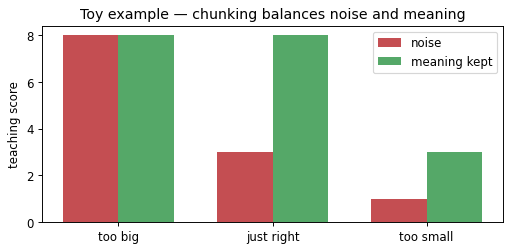

In [11]:
tradeoff_text = "Interns receive 5 vacation days during summer and managers approve Monday remote work."
words = tradeoff_text.replace(".", "").split()

too_big = [tradeoff_text]
just_right = [" ".join(words[:7]) + ".", " ".join(words[7:]) + "."]
too_small = [" ".join(words[i:i+2]) for i in range(0, len(words), 2)]

print("Original text:", tradeoff_text)
print("Too big chunk:", too_big)
print("Just-right chunks:", just_right)
print("Too small chunks:", too_small)

noise_score = [8, 3, 1]       # made-up teaching score: more unrelated words mixed in
meaning_score = [8, 8, 3]     # made-up teaching score: enough words to preserve meaning
labels = ["too big", "just right", "too small"]
print("Noise scores (lower is better):", dict(zip(labels, noise_score)))
print("Meaning scores (higher is better):", dict(zip(labels, meaning_score)))
assert noise_score[1] < noise_score[0]
assert meaning_score[1] > meaning_score[2]

x = np.arange(len(labels))
plt.figure(figsize=(7, 3))
plt.bar(x - 0.18, noise_score, width=0.36, label="noise", color="#C44E52")
plt.bar(x + 0.18, meaning_score, width=0.36, label="meaning kept", color="#55A868")
plt.xticks(x, labels)
plt.ylabel("teaching score")
plt.title("Toy example — chunking balances noise and meaning")
plt.legend()
plt.show()

## Step 4 · Toy example — embed chunks with TF-IDF

An **embedding** is a vector (a list of numbers) that represents text. Real RAG systems often use a
sentence encoder like you saw in M14. Here we use **TF-IDF** from scikit-learn because it is offline,
small, and preinstalled in Colab.

TF-IDF roughly means: a word gets a bigger weight when it appears in this chunk but not everywhere.
The **index** is just the matrix of chunk vectors.

Number of chunks: 9
Vocabulary size: 99
Index shape = rows(chunks) x columns(terms): (9, 99)
First 20 vocabulary terms: ['12', '12 dollar', '15', '15 vacation', '20', '20 minutes', '30', '30 days', 'allowed', 'allowed office', 'analytics', 'analytics logs', 'answers', 'answers urgent', 'approval', 'cafe', 'cafe gives', 'company', 'company cafe', 'credit']
Non-zero weights in C01: 9
Terms shown in heatmap: ['receive vacation', 'security', 'reset password', 'portal', 'password security', 'password', 'security portal', 'friday', 'time', 'receive', 'vacation', 'vacation days', 'reset', 'days']


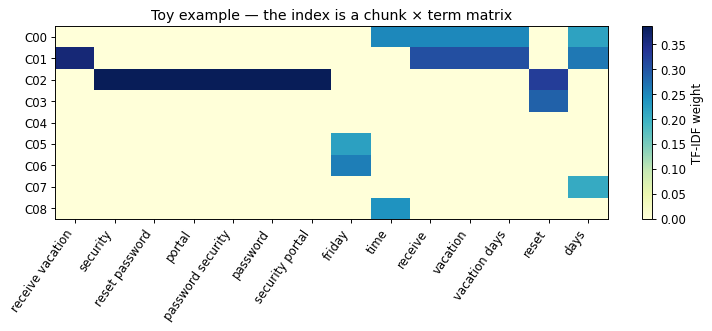

In [13]:
chunk_texts = [c["text"] for c in chunks]
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), lowercase=True)
index = vectorizer.fit_transform(chunk_texts).toarray()
terms = np.array(vectorizer.get_feature_names_out())

print("Number of chunks:", len(chunk_texts))
print("Vocabulary size:", len(terms))
print("Index shape = rows(chunks) x columns(terms):", index.shape)
print("First 20 vocabulary terms:", terms[:20].tolist())
print("Non-zero weights in C01:", int((index[1] > 0).sum()))
assert index.shape[0] == len(chunks)
assert index.shape[1] == len(terms)

top_cols = np.argsort(index.sum(axis=0))[-14:]
heat = index[:, top_cols]
print("Terms shown in heatmap:", terms[top_cols].tolist())

plt.figure(figsize=(9, 4))
plt.imshow(heat, cmap="YlGnBu", aspect="auto")
plt.xticks(range(len(top_cols)), terms[top_cols], rotation=55, ha="right")
plt.yticks(range(len(chunks)), [c["chunk_id"] for c in chunks])
plt.colorbar(label="TF-IDF weight")
plt.title("Toy example — the index is a chunk × term matrix")
plt.tight_layout()
plt.show()

**Good for:** TF-IDF is transparent: you can inspect exactly which words drive retrieval.

**Watch out for:** TF-IDF is mostly lexical. It does not truly understand that "holiday allowance" can
mean "vacation days" unless those words overlap or you add query-understanding help.

## Step 5 · Toy example — inspect one vector

This is what "turn text into numbers" looks like. We print the non-zero coordinates for the intern
vacation chunk.

Chunk inspected: C01 Interns receive 5 vacation days during summer.
Non-zero TF-IDF weights:
  days summer        -> 0.361
  interns            -> 0.361
  interns receive    -> 0.361
  receive vacation   -> 0.361
  summer             -> 0.361
  receive            -> 0.305
  vacation           -> 0.305
  vacation days      -> 0.305
  days               -> 0.265


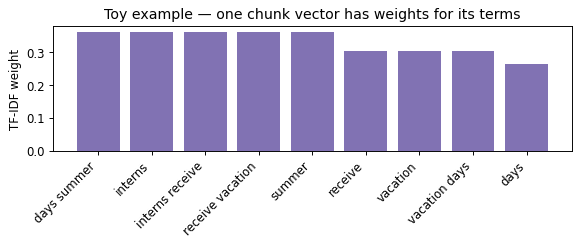

In [16]:
inspect_id = "C01"
inspect_i = [i for i, c in enumerate(chunks) if c["chunk_id"] == inspect_id][0]
weights = index[inspect_i]
nonzero = [(terms[i], float(weights[i])) for i in np.where(weights > 0)[0]]
nonzero = sorted(nonzero, key=lambda x: -x[1])

print("Chunk inspected:", inspect_id, chunks[inspect_i]["text"])
print("Non-zero TF-IDF weights:")
for term, weight in nonzero:
    print(f"  {term:18s} -> {weight:.3f}")
assert any(term == "interns" for term, _ in nonzero)
assert any(term == "vacation days" for term, _ in nonzero)

plt.figure(figsize=(7, 3))
plt.bar([t for t, _ in nonzero], [w for _, w in nonzero], color="#8172B3")
plt.xticks(rotation=45, ha="right")
plt.ylabel("TF-IDF weight")
plt.title("Toy example — one chunk vector has weights for its terms")
plt.tight_layout()
plt.show()

## Step 6 · Toy example — cosine similarity math

Cosine similarity measures whether two vectors point in the same direction:

$\text{cosine}(q, c) = \frac{q \cdot c}{\|q\|\,\|c\|}$

It ranges from **-1** (opposite) to **1** (same direction). With TF-IDF vectors, scores are usually
between 0 and 1 because word weights are non-negative.

## Step 7 · Toy example — query → retrieve top-k

Now the user asks a question. We embed the query with the **same vectorizer** used for chunks, compute
cosine similarity to every chunk, sort from highest to lowest, and take top-k.

Query: How many vacation days do interns receive?
Query terms that exist in the vocabulary:
  days               -> 0.339
  interns            -> 0.462
  interns receive    -> 0.462
  receive            -> 0.390
  vacation           -> 0.390
  vacation days      -> 0.390
Cosine similarity to every chunk:
  C00 (Vacation policy) sim=0.367 text=Full-time employees receive 15 vacation days each year.
  C01 (Vacation policy) sim=0.781 text=Interns receive 5 vacation days during summer.
  C02 (Password reset ) sim=0.000 text=Reset your password from the security portal.
  C03 (Password reset ) sim=0.000 text=A reset link expires after 20 minutes.
  C04 (Lunch benefit  ) sim=0.000 text=The company cafe gives every employee a 12 dollar lunch credit on weekdays.
  C05 (Remote work    ) sim=0.000 text=Team members may work remotely on Monday and Friday with manager approval.
  C06 (Office pets    ) sim=0.000 text=Dogs are allowed in the office on Friday if they are registered with facilities.
 

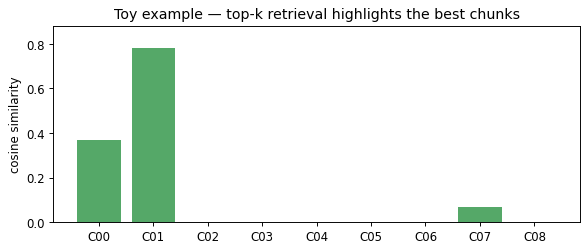

In [19]:
def cosine_scores(query):
    q = vectorizer.transform([query]).toarray()[0]
    q_norm = np.linalg.norm(q)
    idx_norms = np.linalg.norm(index, axis=1)
    if q_norm == 0:
        sims = np.zeros(len(index))
    else:
        sims = (index @ q) / (idx_norms * q_norm + 1e-12)
    return q, sims

def rank_chunks(query, k=3):
    q, sims = cosine_scores(query)
    order = np.argsort(-sims)
    return q, sims, order[:k], order

query = "How many vacation days do interns receive?"
q_vec, sims, topk, order = rank_chunks(query, k=3)
q_terms = [(terms[i], float(q_vec[i])) for i in np.where(q_vec > 0)[0]]

print("Query:", query)
print("Query terms that exist in the vocabulary:")
for term, weight in q_terms:
    print(f"  {term:18s} -> {weight:.3f}")
print("Cosine similarity to every chunk:")
for i, sim in enumerate(sims):
    print(f"  {chunks[i]['chunk_id']} ({chunks[i]['title']:<15s}) sim={sim:.3f} text={chunks[i]['text']}")
print("Ranking best to worst:", [chunks[i]["chunk_id"] for i in order])
print("Top-3:", [chunks[i]["chunk_id"] for i in topk])

expected_i = [i for i, c in enumerate(chunks) if c["chunk_id"] == "C01"][0]
assert order[0] == expected_i
assert np.all(sims <= 1 + 1e-9) and np.all(sims >= -1 - 1e-9)

colors = ["#55A868" if i in topk else "#BBBBBB" for i in range(len(chunks))]
plt.figure(figsize=(8, 3))
plt.bar([c["chunk_id"] for c in chunks], sims, color=colors)
plt.ylabel("cosine similarity")
plt.title("Toy example — top-k retrieval highlights the best chunks")
plt.ylim(0, max(0.05, sims.max() + 0.1))
plt.show()

**Good for:** top-k retrieval gives the generator a short, relevant reading list.

**Watch out for:** the "same vectorizer" rule matters. If chunks and queries use different vector
spaces, cosine scores are meaningless.

## Step 8 · Toy example — retrieval diagram as a heatmap

A heatmap is a picture of a matrix. Here, rows are queries, columns are chunks, and each color shows a
query-to-chunk similarity.

Query: intern vacation days
  best chunk: C01 Interns receive 5 vacation days during summer.
Query: reset password link
  best chunk: C02 Reset your password from the security portal.
Query: urgent support hours
  best chunk: C08 IT support answers urgent tickets from 8 AM to 6 PM Eastern time.
Similarity matrix rounded:
 [[0.415 0.506 0.    0.    0.    0.    0.    0.109 0.   ]
 [0.    0.    0.543 0.301 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.397]]


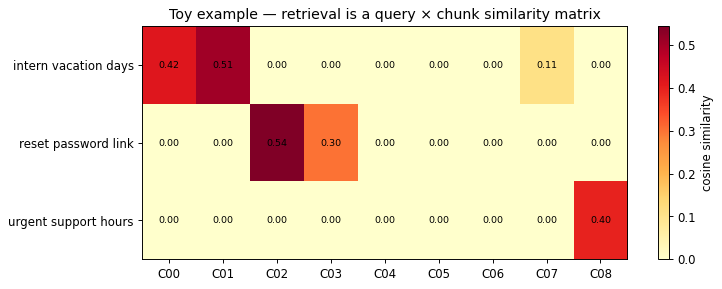

In [22]:
demo_queries = [
    "intern vacation days",
    "reset password link",
    "urgent support hours",
]
sim_matrix = []
for demo_q in demo_queries:
    _, demo_sims, _, demo_order = rank_chunks(demo_q, k=3)
    sim_matrix.append(demo_sims)
    print("Query:", demo_q)
    print("  best chunk:", chunks[demo_order[0]]["chunk_id"], chunks[demo_order[0]]["text"])
sim_matrix = np.vstack(sim_matrix)
print("Similarity matrix rounded:\n", np.round(sim_matrix, 3))

assert chunks[np.argmax(sim_matrix[0])]["chunk_id"] == "C01"
assert chunks[np.argmax(sim_matrix[1])]["doc_id"] == "D2"
assert chunks[np.argmax(sim_matrix[2])]["chunk_id"] == "C08"

plt.figure(figsize=(9, 3.5))
plt.imshow(sim_matrix, cmap="YlOrRd", aspect="auto")
plt.xticks(range(len(chunks)), [c["chunk_id"] for c in chunks])
plt.yticks(range(len(demo_queries)), demo_queries)
for r in range(sim_matrix.shape[0]):
    for c in range(sim_matrix.shape[1]):
        plt.text(c, r, f"{sim_matrix[r, c]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(label="cosine similarity")
plt.title("Toy example — retrieval is a query × chunk similarity matrix")
plt.tight_layout()
plt.show()

## Step 9 · Toy example — top-k context list

Top-1 is the single best chunk. Top-k keeps several chunks in case the answer needs more than one
piece of evidence.

Question: How many vacation days do interns receive?
Retrieved top-3 chunks:
  rank 1: C01  sim=0.781  Interns receive 5 vacation days during summer.
  rank 2: C00  sim=0.367  Full-time employees receive 15 vacation days each year.
  rank 3: C07  sim=0.070  Customer analytics logs are kept for 30 days before deletion.


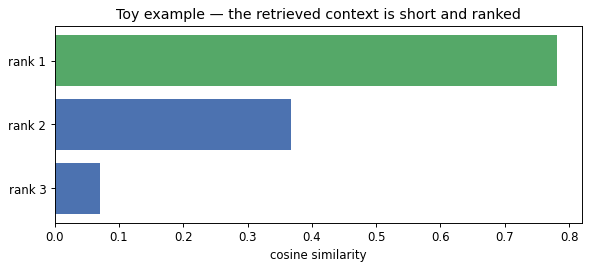

In [24]:
k = 3
retrieved = [chunks[i] for i in topk]
print("Question:", query)
print(f"Retrieved top-{k} chunks:")
for rank, idx in enumerate(topk, 1):
    print(f"  rank {rank}: {chunks[idx]['chunk_id']}  sim={sims[idx]:.3f}  {chunks[idx]['text']}")
assert any(c["chunk_id"] == "C01" for c in retrieved)

plt.figure(figsize=(8, 3))
plt.barh([f"rank {r}" for r in range(k, 0, -1)],
         [sims[i] for i in topk[::-1]],
         color=["#4C72B0", "#4C72B0", "#55A868"])
plt.xlabel("cosine similarity")
plt.title("Toy example — the retrieved context is short and ranked")
plt.show()

---
# Part B · Build the augmented prompt and answer safely

## Step 10 · Toy example — augment the prompt

**Augment** means "add useful extra information." In RAG, we build a prompt that includes the
retrieved chunks plus the user's question. This cell prints the full prompt so there is no mystery.

FULL AUGMENTED PROMPT START
Context:
[C01] Interns receive 5 vacation days during summer.
[C00] Full-time employees receive 15 vacation days each year.
[C07] Customer analytics logs are kept for 30 days before deletion.

Question: How many vacation days do interns receive?
Answer using only the context. If the answer is missing, say you do not know.
FULL AUGMENTED PROMPT END
Context characters: 182
Question characters: 42
Instruction characters: 77


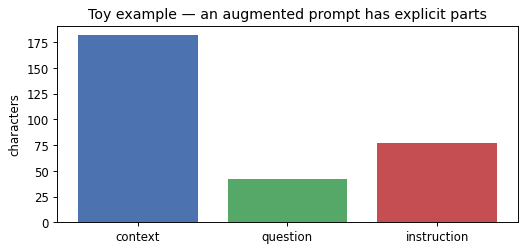

In [27]:
context_block = "\n".join([f"[{c['chunk_id']}] {c['text']}" for c in retrieved])
instruction = "Answer using only the context. If the answer is missing, say you do not know."
prompt = "Context:\n" + context_block + "\n\nQuestion: " + query + "\n" + instruction

print("FULL AUGMENTED PROMPT START")
print(prompt)
print("FULL AUGMENTED PROMPT END")
print("Context characters:", len(context_block))
print("Question characters:", len(query))
print("Instruction characters:", len(instruction))
assert "Context:" in prompt and "Question:" in prompt and "C01" in prompt

parts = ["context", "question", "instruction"]
sizes = [len(context_block), len(query), len(instruction)]
plt.figure(figsize=(7, 3))
plt.bar(parts, sizes, color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("characters")
plt.title("Toy example — an augmented prompt has explicit parts")
plt.show()

**Good for:** making the generator's evidence visible and limited.

**Watch out for:** too much retrieved context can distract the generator or exceed the prompt budget.

## Step 11 · Toy example — generate, but simulated and grounded

This notebook has **no real LLM**. Instead, the "generator" is a tiny extractive function: it returns
an answer built only from retrieved chunks. That makes the grounding rule easy to inspect.

Question: How many vacation days do interns receive?
No-RAG answer: No context answer: interns might get 10 vacation days. (This is a guess.)
RAG grounded answer: Interns receive 5 vacation days during summer. [C01]
Evidence chunk used: C01 Interns receive 5 vacation days during summer.


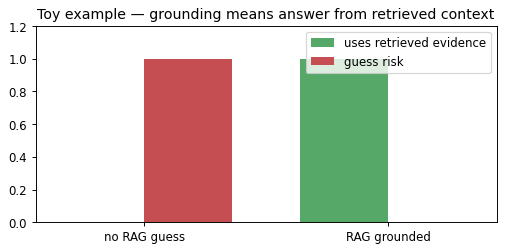

In [30]:
def simulated_grounded_answer(question, retrieved_chunks):
    best = retrieved_chunks[0]
    text = best["text"]
    if "vacation" in question.lower() and "intern" in question.lower():
        return f"Interns receive 5 vacation days during summer. [{best['chunk_id']}]"
    return f"{text} [{best['chunk_id']}]"

grounded_answer = simulated_grounded_answer(query, retrieved)
no_rag_answer = "No context answer: interns might get 10 vacation days. (This is a guess.)"

print("Question:", query)
print("No-RAG answer:", no_rag_answer)
print("RAG grounded answer:", grounded_answer)
print("Evidence chunk used:", retrieved[0]["chunk_id"], retrieved[0]["text"])
assert "5 vacation days" in grounded_answer
assert "[C01]" in grounded_answer

labels = ["no RAG guess", "RAG grounded"]
grounded_score = [0, 1]
guess_risk = [1, 0]
x = np.arange(len(labels))
plt.figure(figsize=(7, 3))
plt.bar(x - 0.18, grounded_score, width=0.36, label="uses retrieved evidence", color="#55A868")
plt.bar(x + 0.18, guess_risk, width=0.36, label="guess risk", color="#C44E52")
plt.xticks(x, labels)
plt.ylim(0, 1.2)
plt.title("Toy example — grounding means answer from retrieved context")
plt.legend()
plt.show()

**Good for:** forcing answers to come from known evidence.

**Watch out for:** a real LLM can still misread context. Grounding reduces hallucination risk; it does
not prove the answer is perfect.

## Step 12 · Toy example — citations

A **citation** points back to the chunk used as evidence. A citation is not magic proof, but it lets a
human check where the answer came from.

Grounded answer: Interns receive 5 vacation days during summer. [C01]
Citation table:
 rank chunk_id           title  score                                                          text
    1      C01 Vacation policy  0.781                Interns receive 5 vacation days during summer.
    2      C00 Vacation policy  0.367       Full-time employees receive 15 vacation days each year.
    3      C07  Data retention  0.070 Customer analytics logs are kept for 30 days before deletion.


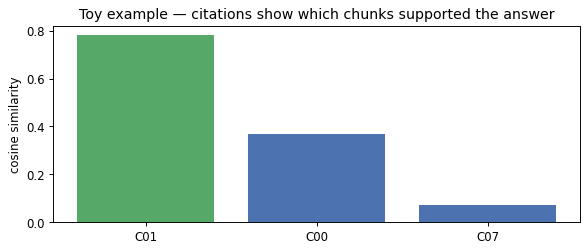

In [33]:
citation_rows = []
for rank, idx in enumerate(topk, 1):
    citation_rows.append({
        "rank": rank,
        "chunk_id": chunks[idx]["chunk_id"],
        "title": chunks[idx]["title"],
        "score": round(float(sims[idx]), 3),
        "text": chunks[idx]["text"],
    })
citations = pd.DataFrame(citation_rows)
print("Grounded answer:", grounded_answer)
print("Citation table:")
print(citations.to_string(index=False))
assert citations.iloc[0]["chunk_id"] == "C01"

plt.figure(figsize=(8, 3))
plt.bar(citations["chunk_id"], citations["score"], color=["#55A868", "#4C72B0", "#4C72B0"])
plt.ylabel("cosine similarity")
plt.title("Toy example — citations show which chunks supported the answer")
plt.show()

## Step 13 · Toy example — grounding and the NO-answer fallback

Sometimes the right answer is not in the knowledge base. A safe RAG system should say **"I don't
know"** instead of hallucinating. We use a threshold: if the best similarity is too low, we refuse to
answer.

Off-topic query: What is the stock price tomorrow?
Query vector non-zero terms: 0
Similarity to every chunk: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Best similarity: 0.0
Threshold: 0.25
Answer: I don't know — that is not in my knowledge base.


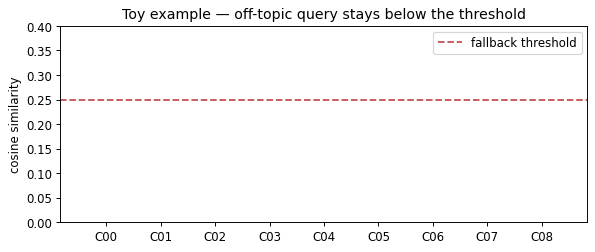

In [35]:
threshold = 0.25
off_topic_query = "What is the stock price tomorrow?"
off_q_vec, off_sims, off_topk, off_order = rank_chunks(off_topic_query, k=3)
off_max = float(off_sims[off_order[0]])

def answer_with_fallback(question, k=3, threshold=0.25):
    q, local_sims, local_topk, local_order = rank_chunks(question, k=k)
    best_score = float(local_sims[local_order[0]])
    if best_score < threshold:
        return "I don't know — that is not in my knowledge base.", local_sims, local_topk, local_order
    local_retrieved = [chunks[i] for i in local_topk]
    return simulated_grounded_answer(question, local_retrieved), local_sims, local_topk, local_order

fallback_answer, checked_sims, checked_topk, checked_order = answer_with_fallback(off_topic_query, threshold=threshold)
print("Off-topic query:", off_topic_query)
print("Query vector non-zero terms:", int((off_q_vec > 0).sum()))
print("Similarity to every chunk:", np.round(off_sims, 3).tolist())
print("Best similarity:", round(off_max, 3))
print("Threshold:", threshold)
print("Answer:", fallback_answer)
assert off_max < threshold
assert fallback_answer.startswith("I don't know")

plt.figure(figsize=(8, 3))
plt.bar([c["chunk_id"] for c in chunks], off_sims, color="#BBBBBB")
plt.axhline(threshold, color="#C44E52", linestyle="--", label="fallback threshold")
plt.ylabel("cosine similarity")
plt.title("Toy example — off-topic query stays below the threshold")
plt.legend()
plt.ylim(0, threshold + 0.15)
plt.show()

**Good for:** avoiding confident answers when retrieval finds weak evidence.

**Watch out for:** threshold tuning is a product decision. Too high rejects answerable questions; too
low allows weak, risky answers. This connects to M19 query understanding.

## Step 14 · Toy example — threshold tuning intuition

We compare maximum similarity for known questions and unknown questions. A simple threshold should
separate them on this toy corpus.

known vacation   max similarity=0.781 best=C01
known password   max similarity=0.636 best=C02
unknown stock    max similarity=0.000 best=C00
unknown menu     max similarity=0.000 best=C00


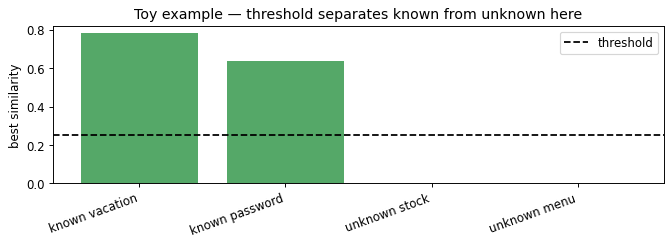

In [38]:
threshold_examples = [
    ("known vacation", "How many vacation days do interns receive?"),
    ("known password", "How do I reset my password?"),
    ("unknown stock", "What is the stock price tomorrow?"),
    ("unknown menu", "What is the cafeteria menu today?"),
]
max_scores = []
for label, q in threshold_examples:
    _, local_sims, _, local_order = rank_chunks(q, k=3)
    m = float(local_sims[local_order[0]])
    max_scores.append(m)
    print(f"{label:16s} max similarity={m:.3f} best={chunks[local_order[0]]['chunk_id']}")

assert max_scores[0] > threshold
assert max_scores[1] > threshold
assert max_scores[2] < threshold
assert max_scores[3] < threshold

colors = ["#55A868" if s >= threshold else "#C44E52" for s in max_scores]
plt.figure(figsize=(8, 3))
plt.bar([x[0] for x in threshold_examples], max_scores, color=colors)
plt.axhline(threshold, color="black", linestyle="--", label="threshold")
plt.ylabel("best similarity")
plt.title("Toy example — threshold separates known from unknown here")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

---
# Part C · Evaluate and spot gotchas

## Step 15 · Toy example — retrieval recall@k

**Recall@k** asks: "Was the correct chunk somewhere in the top-k?" If the answer is in top-3 but not
top-1, a generator might still have enough context.

Question: How many vacation days do interns receive?
  expected: C01 top-3: ['C01', 'C00', 'C07'] hit@1: True hit@3: True
Question: Where do I reset my password?
  expected: C02 top-3: ['C02', 'C03', 'C00'] hit@1: True hit@3: True
Question: How much is the lunch credit?
  expected: C04 top-3: ['C04', 'C00', 'C01'] hit@1: True hit@3: True
Question: When is IT support open?
  expected: C08 top-3: ['C08', 'C00', 'C01'] hit@1: True hit@3: True
Question: Can dogs come to the office Friday?
  expected: C06 top-3: ['C06', 'C05', 'C00'] hit@1: True hit@3: True
recall@1: 1.0
recall@3: 1.0


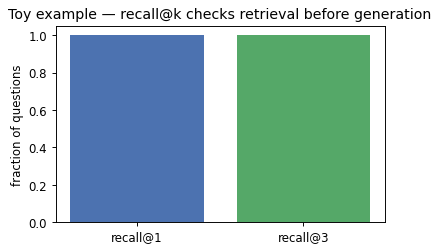

In [41]:
eval_set = [
    ("How many vacation days do interns receive?", "C01"),
    ("Where do I reset my password?", "C02"),
    ("How much is the lunch credit?", "C04"),
    ("When is IT support open?", "C08"),
    ("Can dogs come to the office Friday?", "C06"),
]

hit1 = []
hit3 = []
for q, expected_chunk in eval_set:
    _, local_sims, local_top3, local_order = rank_chunks(q, k=3)
    top_ids = [chunks[i]["chunk_id"] for i in local_top3]
    h1 = top_ids[0] == expected_chunk
    h3 = expected_chunk in top_ids
    hit1.append(h1)
    hit3.append(h3)
    print("Question:", q)
    print("  expected:", expected_chunk, "top-3:", top_ids, "hit@1:", h1, "hit@3:", h3)

recall1 = float(np.mean(hit1))
recall3 = float(np.mean(hit3))
print("recall@1:", recall1)
print("recall@3:", recall3)
assert recall3 >= recall1
assert recall3 >= 0.8

plt.figure(figsize=(5, 3))
plt.bar(["recall@1", "recall@3"], [recall1, recall3], color=["#4C72B0", "#55A868"])
plt.ylim(0, 1.05)
plt.ylabel("fraction of questions")
plt.title("Toy example — recall@k checks retrieval before generation")
plt.show()

**Good for:** measuring the retrieval part separately before blaming the generator.

**Watch out for:** a tiny eval set can be misleading. Real systems need many representative questions
and human-reviewed expected chunks.

## Step 16 · Toy example — stale index problem

If the corpus changes but the index is not rebuilt, retrieval cannot find the new fact. This is called
a **stale index**.

New fact not in old index: Makers can reserve the prototype lab on Wednesday afternoon.
Question: When can makers reserve the prototype lab?
Old index best chunk: C00 score 0.0
Rebuilt vocabulary includes: ['makers', 'prototype', 'lab', 'wednesday']
Rebuilt index best chunk: C09 score 0.798


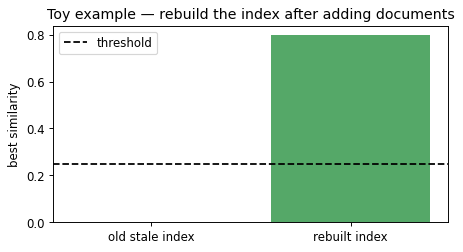

In [44]:
new_chunk = {
    "chunk_id": "C09",
    "doc_id": "D8",
    "title": "Maker lab",
    "sentence": 0,
    "text": "Makers can reserve the prototype lab on Wednesday afternoon.",
}
new_question = "When can makers reserve the prototype lab?"

_, stale_sims, _, stale_order = rank_chunks(new_question, k=3)
stale_best = float(stale_sims[stale_order[0]])
print("New fact not in old index:", new_chunk["text"])
print("Question:", new_question)
print("Old index best chunk:", chunks[stale_order[0]]["chunk_id"], "score", round(stale_best, 3))

rebuilt_chunks = chunks + [new_chunk]
rebuilt_texts = [c["text"] for c in rebuilt_chunks]
rebuilt_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), lowercase=True)
rebuilt_index = rebuilt_vectorizer.fit_transform(rebuilt_texts).toarray()
rebuilt_terms = np.array(rebuilt_vectorizer.get_feature_names_out())
rebuilt_q = rebuilt_vectorizer.transform([new_question]).toarray()[0]
rebuilt_sims = (rebuilt_index @ rebuilt_q) / (np.linalg.norm(rebuilt_index, axis=1) * np.linalg.norm(rebuilt_q) + 1e-12)
rebuilt_order = np.argsort(-rebuilt_sims)
rebuilt_best_chunk = rebuilt_chunks[rebuilt_order[0]]
print("Rebuilt vocabulary includes:", [t for t in ["makers", "prototype", "lab", "wednesday"] if t in set(rebuilt_terms)])
print("Rebuilt index best chunk:", rebuilt_best_chunk["chunk_id"], "score", round(float(rebuilt_sims[rebuilt_order[0]]), 3))
assert stale_best < threshold
assert rebuilt_best_chunk["chunk_id"] == "C09"

plt.figure(figsize=(6, 3))
plt.bar(["old stale index", "rebuilt index"], [stale_best, float(rebuilt_sims[rebuilt_order[0]])],
        color=["#C44E52", "#55A868"])
plt.axhline(threshold, color="black", linestyle="--", label="threshold")
plt.ylabel("best similarity")
plt.title("Toy example — rebuild the index after adding documents")
plt.legend()
plt.show()

**Good for:** remembering that indexing is part of the production system, not a one-time notebook
cell.

**Watch out for:** deleted or edited documents also need index updates, or citations can point to old
facts.

## Step 17 · Toy example — embedding quality and synonyms

TF-IDF does not know every synonym. A person may ask "holiday allowance" while the corpus says
"vacation days." Better sentence encoders or query understanding can help, but here we show the issue
offline with a tiny rewrite.

Original synonym-heavy query: How much holiday allowance do trainees have?
Original best: C00 score 0.0
Expanded query: How much holiday allowance do trainees have? vacation days interns
Expanded best: C01 score 0.621
Why it changed: the expansion adds words that exist in the corpus vocabulary.


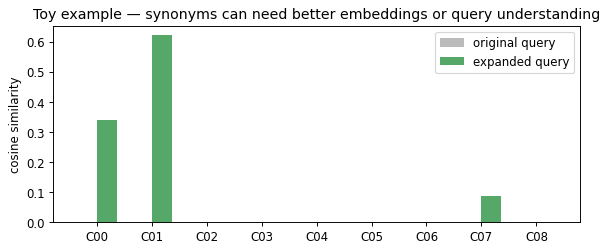

In [47]:
synonym_query = "How much holiday allowance do trainees have?"
expanded_query = synonym_query + " vacation days interns"

_, syn_sims, _, syn_order = rank_chunks(synonym_query, k=3)
_, exp_sims, _, exp_order = rank_chunks(expanded_query, k=3)
raw_best = float(syn_sims[syn_order[0]])
expanded_best = float(exp_sims[exp_order[0]])

print("Original synonym-heavy query:", synonym_query)
print("Original best:", chunks[syn_order[0]]["chunk_id"], "score", round(raw_best, 3))
print("Expanded query:", expanded_query)
print("Expanded best:", chunks[exp_order[0]]["chunk_id"], "score", round(expanded_best, 3))
print("Why it changed: the expansion adds words that exist in the corpus vocabulary.")
assert raw_best < threshold
assert chunks[exp_order[0]]["chunk_id"] == "C01"
assert expanded_best > raw_best

x = np.arange(len(chunks))
plt.figure(figsize=(8, 3))
plt.bar(x - 0.18, syn_sims, width=0.36, label="original query", color="#BBBBBB")
plt.bar(x + 0.18, exp_sims, width=0.36, label="expanded query", color="#55A868")
plt.xticks(x, [c["chunk_id"] for c in chunks])
plt.ylabel("cosine similarity")
plt.title("Toy example — synonyms can need better embeddings or query understanding")
plt.legend()
plt.show()

**Good for:** seeing why embedding quality matters before adding a real LLM.

**Watch out for:** query rewrites can add the wrong words. Always evaluate rewrites and retrieval
together.

## Step 18 · Toy example — the whole module as one chain

This final cell runs the full RAG chain twice: one answerable question and one off-topic question.


--- RAG CHAIN START ---
Question: How many vacation days do interns receive?
Step 1 embed query: non-zero query terms = 6
Step 2 retrieve: scores = [0.367, 0.781, 0.0, 0.0, 0.0, 0.0, 0.0, 0.07, 0.0]
Step 3 rank: top-k = ['C01', 'C00', 'C07']
Step 4 threshold check: best = 0.781 threshold = 0.25
Step 5 augment context: ['C01', 'C00', 'C07']
Step 6 answer: Interns receive 5 vacation days during summer. [C01]
--- RAG CHAIN END ---

--- RAG CHAIN START ---
Question: What is the stock price tomorrow?
Step 1 embed query: non-zero query terms = 0
Step 2 retrieve: scores = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Step 3 rank: top-k = ['C00', 'C01', 'C02']
Step 4 threshold check: best = 0.0 threshold = 0.25
Step 6 answer: I don't know — that is not in my knowledge base.
--- RAG CHAIN END ---


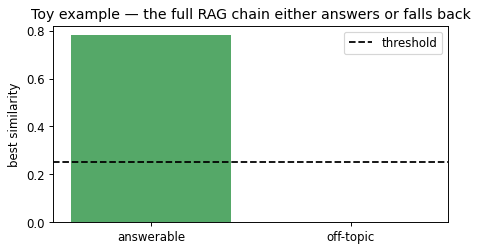

In [50]:
def rag_chain(question, k=3, threshold=0.25):
    print("\n--- RAG CHAIN START ---")
    print("Question:", question)
    q, local_sims, local_topk, local_order = rank_chunks(question, k=k)
    print("Step 1 embed query: non-zero query terms =", int((q > 0).sum()))
    print("Step 2 retrieve: scores =", np.round(local_sims, 3).tolist())
    print("Step 3 rank: top-k =", [chunks[i]["chunk_id"] for i in local_topk])
    best = float(local_sims[local_order[0]])
    print("Step 4 threshold check: best =", round(best, 3), "threshold =", threshold)
    if best < threshold:
        answer = "I don't know — that is not in my knowledge base."
        used = []
    else:
        used = [chunks[i] for i in local_topk]
        print("Step 5 augment context:", [c["chunk_id"] for c in used])
        answer = simulated_grounded_answer(question, used)
    print("Step 6 answer:", answer)
    print("--- RAG CHAIN END ---")
    return {"question": question, "answer": answer, "best": best, "used": used}

chain_known = rag_chain("How many vacation days do interns receive?", threshold=threshold)
chain_unknown = rag_chain("What is the stock price tomorrow?", threshold=threshold)
assert "5 vacation days" in chain_known["answer"]
assert chain_unknown["answer"].startswith("I don't know")

plt.figure(figsize=(6, 3))
plt.bar(["answerable", "off-topic"], [chain_known["best"], chain_unknown["best"]],
        color=["#55A868", "#C44E52"])
plt.axhline(threshold, color="black", linestyle="--", label="threshold")
plt.ylabel("best similarity")
plt.title("Toy example — the full RAG chain either answers or falls back")
plt.legend()
plt.show()

## Recap — M18 RAG in one page

- **RAG = retrieve, then generate.** It helps when the answer should come from a known corpus.
- **Corpus → chunks:** split documents into searchable pieces. Too big is noisy; too small loses
  meaning.
- **Embed → index:** convert chunks into vectors. Here, TF-IDF stands in for a real sentence encoder.
- **Query → retrieve top-k:** embed the query with the same vectorizer, compute cosine similarity, and
  rank chunks.
- **Augment prompt:** pass retrieved chunks plus the question to the generator.
- **Generate grounded answer:** in this notebook, a simulated answerer only uses retrieved chunks.
- **Citations + fallback:** cite chunk IDs and say "I don't know" when max similarity is below a
  threshold.
- **Evaluate retrieval:** recall@k, stale-index checks, chunk quality, and embedding quality all matter
  before a real LLM is added.

The beginner mental model: **the generator is only as grounded as the context retrieval gives it.**